# Clusterização no MovieLens 1M
Romain Sebire - 125009460

## Importação das bibliotecas e download dos dados da internet

In [357]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform
import os
import urllib.request
import zipfile
from collections import Counter
from sklearn.metrics import pairwise_distances
from scipy.stats import zscore

In [327]:
# Download dos dados
# Criar uma pasta para os dados
os.makedirs("data", exist_ok=True)

# URLs dos arquivos
url_zip = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
url_readme = "https://files.grouplens.org/datasets/movielens/ml-1m-README.txt"

# Caminhos locais
zip_path = os.path.join("data", "ml-1m.zip")
readme_path = os.path.join("data", "ml-1m.README")
extract_dir = os.path.join("data", "ml-1m")

# Baixar o arquivo ZIP
if not os.path.exists(zip_path):
    print("Baixando o arquivo ZIP...")
    urllib.request.urlretrieve(url_zip, zip_path)
else:
    print("ZIP já baixado.")

# Baixar o arquivo README
if not os.path.exists(readme_path):
    print("Baixando o README...")
    urllib.request.urlretrieve(url_readme, readme_path)
else:
    print("README já baixado.")

# Extrair o arquivo ZIP
if not os.path.exists(extract_dir):
    print("Extraindo o ZIP...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data")
else:
    print("Pasta já extraída.")


Baixando o arquivo ZIP...
Baixando o README...
Extraindo o ZIP...


In [358]:
# Carregar dados
ratings = pd.read_csv('data/ml-1m/ratings.dat', sep='::', engine='python', names=['user_id','movie_id','rating','timestamp'])
movies = pd.read_csv('data/ml-1m/movies.dat', sep='::', engine='python', encoding='latin1', names=['movie_id','title','genres'])

## Análise exploratória dos dados

In [329]:
# Verificamos as primeiras linhas para confirmar a importação correta dos dados e observar a estrutura
print("=== Avaliações ===")
print(ratings.head(5))

print("\n=== Filmes ===")
print(movies.head(5))

=== Avaliações ===
   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291

=== Filmes ===
   movie_id                               title                        genres
0         1                    Toy Story (1995)   Animation|Children's|Comedy
1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
2         3             Grumpier Old Men (1995)                Comedy|Romance
3         4            Waiting to Exhale (1995)                  Comedy|Drama
4         5  Father of the Bride Part II (1995)                        Comedy


In [330]:
# Análise exploratória dos dados
print("Avaliações:", len(ratings))
print("Usuários:", ratings['user_id'].nunique())
print("Filmes:", ratings['movie_id'].nunique())
all_genres = movies['genres'].str.split('|').explode().unique()
print("Gêneros diferentes:", len(all_genres))

Avaliações: 1000209
Usuários: 6040
Filmes: 3706
Gêneros diferentes: 18


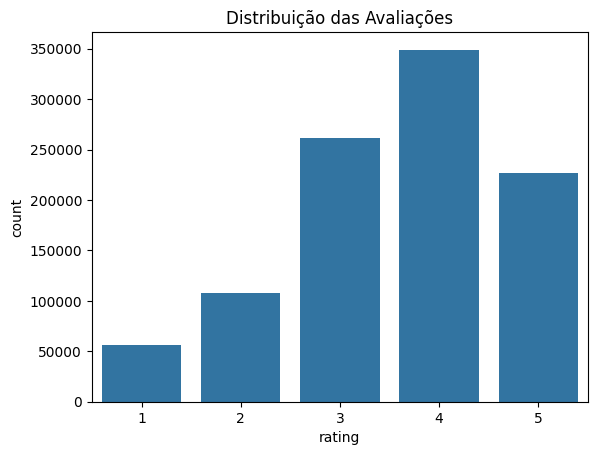

In [331]:
# Distribuição das avaliações
sns.countplot(data=ratings, x='rating'); 
plt.title('Distribuição das Avaliações'); 
plt.show()

Primeiro quartil (Q1): 44.0
Terceiro quartil (Q3): 208.0


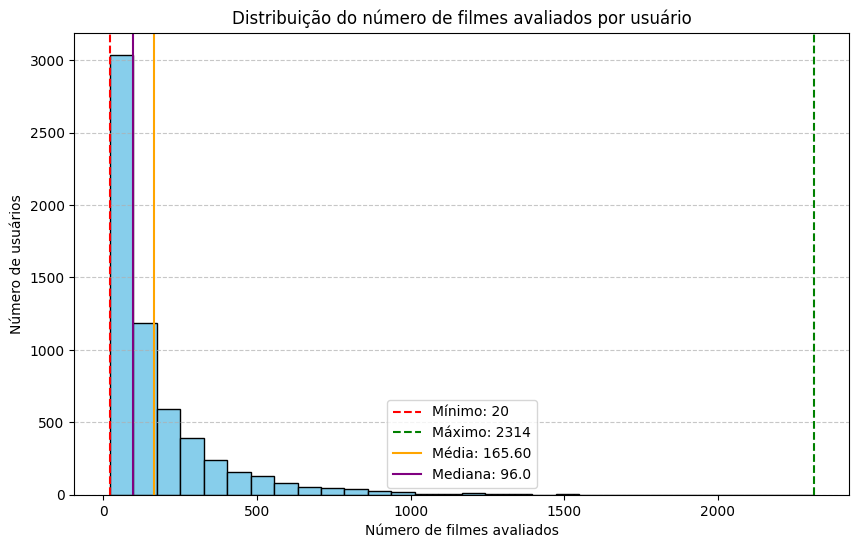

In [164]:
#Distribuição do número de filmes avaliados por usuário
# Contar quantos filmes cada usuário avaliou
ratings_per_user = ratings.groupby("user_id")["movie_id"].count()

# Calcular estatísticas
min_ratings = ratings_per_user.min()
max_ratings = ratings_per_user.max()
mean_ratings = ratings_per_user.mean()
median_ratings = ratings_per_user.median()

# Q1 = 25º percentil (primeiro quartil)
q1 = ratings_per_user.quantile(0.25)
# Q3 = 75º percentil (terceiro quartil)
q3 = ratings_per_user.quantile(0.75)

print(f"Primeiro quartil (Q1): {q1}")
print(f"Terceiro quartil (Q3): {q3}")

# Criar o gráfico de distribuição
plt.figure(figsize=(10, 6))
plt.hist(ratings_per_user, bins=30, color="skyblue", edgecolor="black")
plt.title("Distribuição do número de filmes avaliados por usuário")
plt.xlabel("Número de filmes avaliados")
plt.ylabel("Número de usuários")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar linhas verticais para mínimo, máximo, média e mediana
plt.axvline(min_ratings, color='red', linestyle='--', label=f'Mínimo: {min_ratings}')
plt.axvline(max_ratings, color='green', linestyle='--', label=f'Máximo: {max_ratings}')
plt.axvline(mean_ratings, color='orange', linestyle='-', label=f'Média: {mean_ratings:.2f}')
plt.axvline(median_ratings, color='purple', linestyle='-', label=f'Mediana: {median_ratings}')

plt.legend()
plt.show()



Observamos alguns valores extremos, usuários que avaliaram até 2300 filmes. Talvez seja necessário removê-los, pois esses pontos estarão muito distantes dos demais.

Primeiro quartil (Q1): 33.0
Terceiro quartil (Q3): 350.0


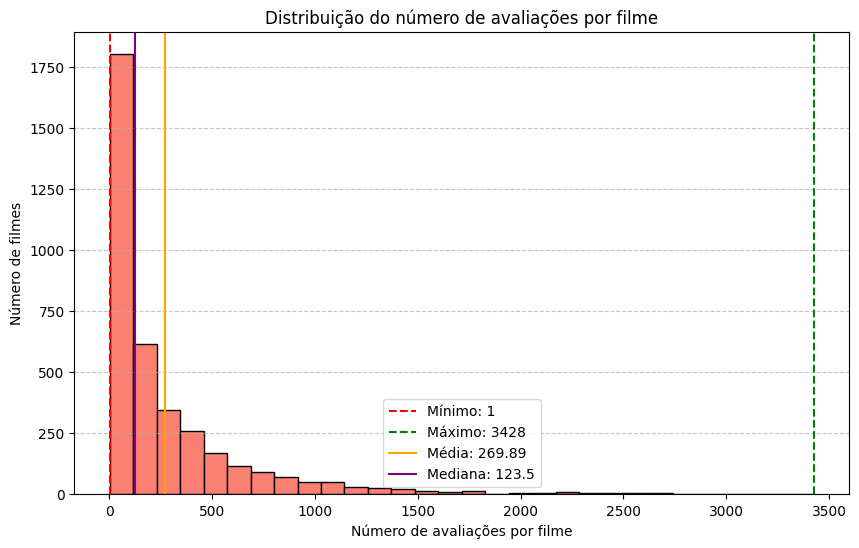

In [165]:
# Distribuição do número de avaliações por filme
# Contar quantas avaliações cada filme recebeu
ratings_per_movie = ratings.groupby("movie_id")["user_id"].count()

# Calcular estatísticas
min_ratings = ratings_per_movie.min()
max_ratings = ratings_per_movie.max()
mean_ratings = ratings_per_movie.mean()
median_ratings = ratings_per_movie.median()

# Q1 = 25º percentil (primeiro quartil)
q1 = ratings_per_movie.quantile(0.25)
# Q3 = 75º percentil (terceiro quartil)
q3 = ratings_per_movie.quantile(0.75)

print(f"Primeiro quartil (Q1): {q1}")
print(f"Terceiro quartil (Q3): {q3}")

# Criar o gráfico de distribuição
plt.figure(figsize=(10, 6))
plt.hist(ratings_per_movie, bins=30, color="salmon", edgecolor="black")
plt.title("Distribuição do número de avaliações por filme")
plt.xlabel("Número de avaliações por filme")
plt.ylabel("Número de filmes")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar linhas verticais para mínimo, máximo, média e mediana
plt.axvline(min_ratings, color='red', linestyle='--', label=f'Mínimo: {min_ratings}')
plt.axvline(max_ratings, color='green', linestyle='--', label=f'Máximo: {max_ratings}')
plt.axvline(mean_ratings, color='orange', linestyle='-', label=f'Média: {mean_ratings:.2f}')
plt.axvline(median_ratings, color='purple', linestyle='-', label=f'Mediana: {median_ratings}')

plt.legend()
plt.show()


Pelo menos um filme recebeu apenas uma única avaliação, então provavelmente será necessário removê-lo para evitar enviesar a análise.

Primeiro quartil (Q1): 40516.75
Terceiro quartil (Q3): 154851.25


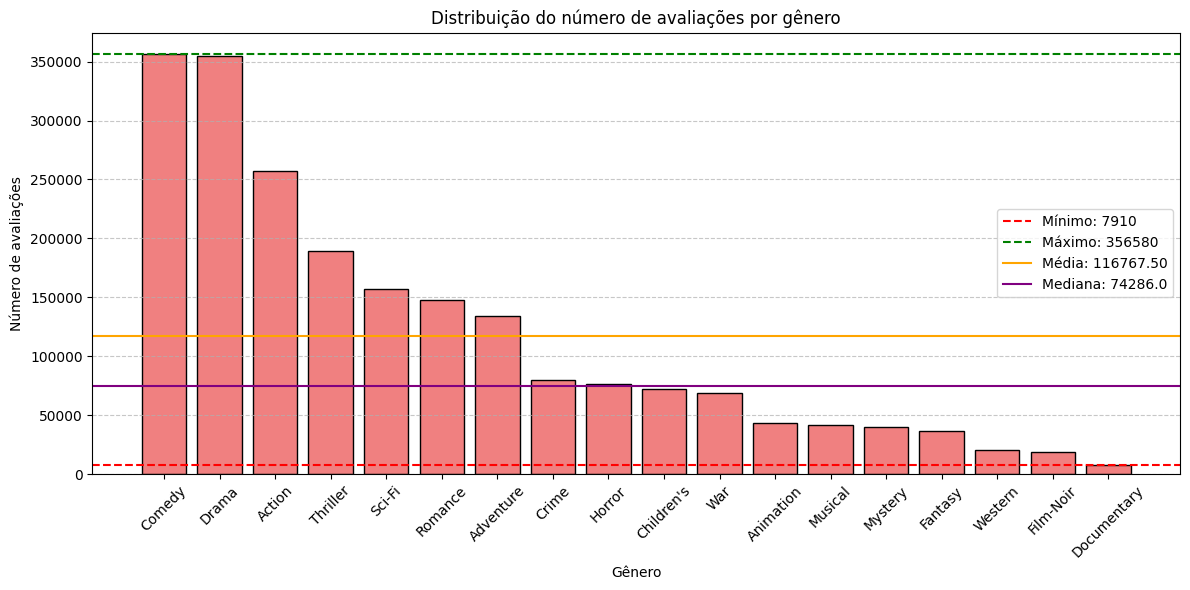

In [166]:
# Distribuição do número de avaliações por gênero
# Mesclar ratings com os gêneros dos filmes
ratings_with_genres = ratings.merge(movies[['movie_id', 'genres']], on='movie_id')

# Separar os gêneros em listas
ratings_with_genres['genre_list'] = ratings_with_genres['genres'].str.split('|')

# Explodir para ter uma linha por gênero
exploded = ratings_with_genres.explode('genre_list')

# Contar o número de avaliações por gênero
ratings_per_genre = exploded['genre_list'].value_counts()

# Calcular estatísticas
min_ratings = ratings_per_genre.min()
max_ratings = ratings_per_genre.max()
mean_ratings = ratings_per_genre.mean()
median_ratings = ratings_per_genre.median()
q1 = ratings_per_genre.quantile(0.25)
q3 = ratings_per_genre.quantile(0.75)

print(f"Primeiro quartil (Q1): {q1}")
print(f"Terceiro quartil (Q3): {q3}")

# Criar o gráfico de distribuição
plt.figure(figsize=(12, 6))
plt.bar(ratings_per_genre.index, ratings_per_genre.values, color="lightcoral", edgecolor="black")
plt.title("Distribuição do número de avaliações por gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de avaliações")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar linhas horizontais para mínimo, máximo, média e mediana
plt.axhline(min_ratings, color='red', linestyle='--', label=f'Mínimo: {min_ratings}')
plt.axhline(max_ratings, color='green', linestyle='--', label=f'Máximo: {max_ratings}')
plt.axhline(mean_ratings, color='orange', linestyle='-', label=f'Média: {mean_ratings:.2f}')
plt.axhline(median_ratings, color='purple', linestyle='-', label=f'Mediana: {median_ratings}')

plt.legend()
plt.tight_layout()
plt.show()


Western, film-noir e documentary são os gêneros com menos avaliações.

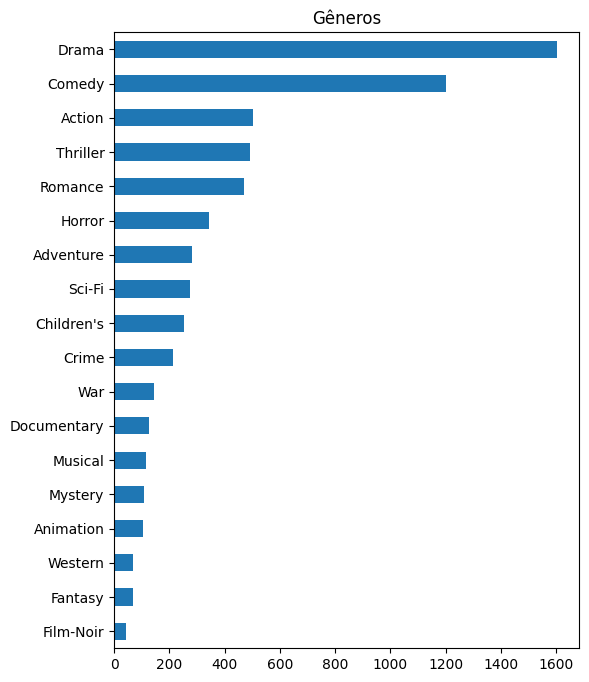

In [10]:
# Distribuição de gêneros
genres = movies['genres'].str.get_dummies(sep='|')
genres.sum().sort_values().plot(kind='barh', figsize=(6,8)); plt.title('Gêneros'); plt.show()

Western, film-noir e documentary são os gêneros menos representados na nossa lista de filmes, o que explica por que receberam menos avaliações.

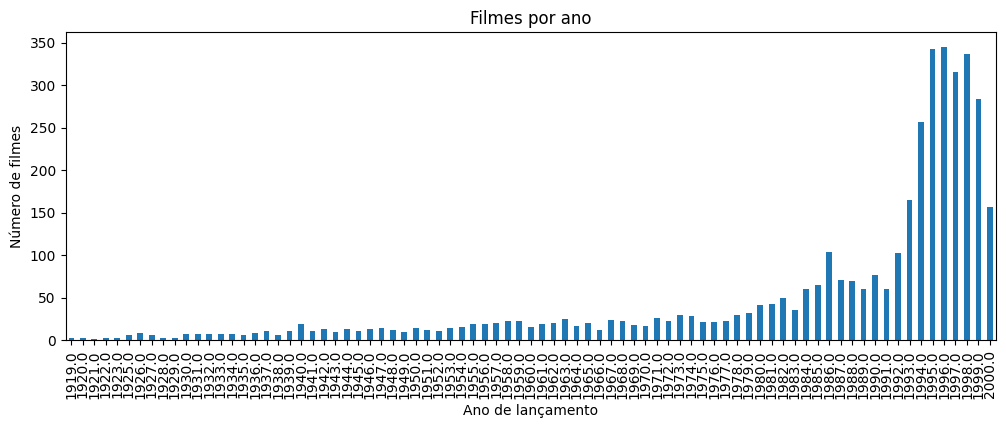

In [167]:
# Filmes por ano
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['year'].value_counts().sort_index().plot(kind='bar', figsize=(12,4));
plt.title('Filmes por ano')
plt.xlabel('Ano de lançamento')
plt.ylabel('Número de filmes')
plt.show()

## Pré-processamento dos dados

In [332]:
# Verifique se há algum valor duplicado
print('Duplicatas ratings:', ratings.duplicated().sum(), '| Duplicatas movies:', movies.duplicated().sum())

Duplicatas ratings: 0 | Duplicatas movies: 0


Nenhuma avaliação ou filme duplicado.

Criação da matriz usuário_filme, é uma matriz onde cada linha representa um usuário, cada coluna representa um filme, e o valor é a nota atribuída pelo usuário ao filme.

Substituímos os valores ausentes por 0, depois de tentar substituir pela nota média dos filmes, mas isso adicionou ruído e os clusters permaneceram os mesmos na análise.

In [359]:
# Criação da matriz usuário_filme
user_movie_matrix = ratings.pivot(index='user_id', columns='movie_id', values='rating')
user_movie_matrix = user_movie_matrix.fillna(0)

Usamos o StandardScaler para centralizar os dados em zero e reduzir a variância, o que ajuda a diminuir as distâncias entre os pontos de forma uniforme. Isso melhora o desempenho dos algoritmos de clustering baseados em distância. Preferimos StandardScaler ao invés do MinMaxScaler porque ele mantém a distribuição dos dados e lida melhor com valores extremos, importantes no nosso conjunto de notas.

In [360]:
# Padronização
scaler = StandardScaler()
user_movie_scaled = scaler.fit_transform(user_movie_matrix)

## Aplicação dos algoritmos de clusterização

Aplicação dos algoritmos de clusterização KMeans, DBScan e Agglomerative com parâmetros padrão, medição da eficiência com a métrica silhouette e exibição do número de elementos por cluster para identificar os clusters com apenas um ou dois outliers.

In [361]:
# Clusterização

print("====== KMeans ======")
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(user_movie_scaled)
print(f"Silhouette KMeans: {silhouette_score(user_movie_scaled, kmeans_labels):.4f}")
print("Número de elementos por cluster:", np.bincount(kmeans_labels), "\n")

print("====== DBSCAN ======")
dbscan = DBSCAN(eps=3, min_samples=5)
dbscan_labels = dbscan.fit_predict(user_movie_scaled)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Clusters DBSCAN (excluindo outliers): {n_clusters_dbscan}")
cluster_counts = Counter(dbscan_labels)
print("Número de elementos por cluster:")
for label, count in sorted(cluster_counts.items()):
    print(f"  Cluster {label}: {count}")
print()

print("====== Agglomerative ======")
agglo = AgglomerativeClustering(n_clusters=5)
agglo_labels = agglo.fit_predict(user_movie_scaled)
print(f"Silhouette Agglomerative: {silhouette_score(user_movie_scaled, agglo_labels):.4f}")
print("Número de elementos por cluster:", np.bincount(agglo_labels))


====== KMeans ======
Silhouette KMeans: 0.7366
Número de elementos por cluster: [   2 6036    2] 

====== DBSCAN ======
Clusters DBSCAN (excluindo outliers): 0
Número de elementos por cluster:
  Cluster -1: 6040

====== Agglomerative ======
Silhouette Agglomerative: 0.2461
Número de elementos por cluster: [1505 4339  194    1    1]


- KMeans obtém uma pontuação muito alta, mas nota-se uma má clusterização, todos os dados ficam em um mesmo cluster e os outros clusters são outliers, será necessário remover os outliers.
- DBScan não consegue identificar clusters, a dimensionalidade está muito alta no momento.
- Agglomerative também identificou clusters com outliers.

## Remoção de Outliers

Diante dos resultados anteriores, devemos remover os valores extremos para evitar a identificação de clusters formados apenas por esses valores.

Atualmente, não utilizamos mais o DBSCAN para identificar outliers, pois a dimensionalidade dos dados continua sendo alta e o algoritmo não consegue formar clusters significativos. Isso impede uma separação confiável entre pontos normais e outliers com essa abordagem.

Em vez disso, adotamos uma estratégia em três etapas para limpar os dados antes da clusterização:

- Filtragem baseada na quantidade de avaliações:

    - Primeiro, removemos usuários com número de avaliações muito baixo ou muito alto, ou seja, fora do intervalo entre os percentis 5% e 95%.

    - Em seguida, aplicamos o mesmo filtro aos filmes, mantendo apenas aqueles que receberam uma quantidade razoável de avaliações (também entre os percentis 5% e 95%).

In [362]:
# 1. Contar quantos filmes cada usuário avaliou
ratings_per_user = ratings.groupby("user_id")["movie_id"].count()

# 2. Contar quantas avaliações cada filme recebeu
ratings_per_movie = ratings.groupby("movie_id")["user_id"].count()

# 3. Cálculo dos percentis (5% e 95%)
q05_user = ratings_per_user.quantile(0.05)
q95_user = ratings_per_user.quantile(0.95)
q05_movie = ratings_per_movie.quantile(0.05)
q95_movie = ratings_per_movie.quantile(1)

# 4. Manter apenas os usuários entre os percentis definidos
filtered_users = ratings_per_user[(ratings_per_user >= q05_user) & (ratings_per_user <= q95_user)]

# 5. Manter apenas os filmes entre os percentis definidos
filtered_movies = ratings_per_movie[(ratings_per_movie >= q05_movie) & (ratings_per_movie <= q95_movie)]

# 6. Filtrar a matriz original com os usuários e filmes selecionados
user_movie_matrix_clean = user_movie_matrix.loc[filtered_users.index, filtered_movies.index]

- Padronização dos dados:

    - Após remover usuários e filmes extremos, padronizamos a matriz de notas para que cada variável (filme) tenha média 0 e desvio padrão 1, o que é essencial para cálculos de distância em espaços de alta dimensão.

In [363]:
# 7. Padronizar os dados
scaler = StandardScaler()
user_movie_scaled_clean = scaler.fit_transform(user_movie_matrix_clean)

- Detecção de outliers com base na distância aos k vizinhos mais próximos:
   
    - Calculamos a matriz de distâncias entre todos os usuários (após o pré-filtragem), usando distância euclidiana.

    - Para cada usuário, identificamos os 5 vizinhos mais próximos (excluindo ele mesmo) e calculamos a média dessas distâncias.

    - Aplicamos um Z-score sobre essas médias para detectar quais usuários estão anormalmente distantes dos demais.

    - Usuários com Z-score acima de 3 são considerados outliers e removidos da matriz.

In [364]:
# 8. Calcular a matriz de distâncias entre usuários
dist_matrix = pairwise_distances(user_movie_scaled_clean, metric='euclidean')

# 9. Calcular a média das distâncias aos k vizinhos mais próximos (sem contar o próprio)
k = 5
sorted_dists = np.sort(dist_matrix, axis=1)[:, 1:k+1]
mean_k_dist = sorted_dists.mean(axis=1)

# 10. Detectar outliers usando Z-score
z_scores_k = zscore(mean_k_dist)
outliers_knn = np.where(z_scores_k > 3)[0]
print(f"{len(outliers_knn)} outliers detectados via distância aos {k} vizinhos mais próximos")

68 outliers detectados via distância aos 5 vizinhos mais próximos


In [365]:
# 11. Remover os outliers da matriz original filtrada
user_movie_matrix_clean = user_movie_matrix_clean.drop(user_movie_matrix_clean.index[outliers_knn])

Após a remoção dos outliers, é necessário repadronizar os dados porque a distribuição original foi alterada. Isso garante que todas as variáveis mantenham média zero e desvio padrão igual a um.


In [366]:
# 12. Repadronizar os dados finais
scaler = StandardScaler()
user_movie_scaled_clean = scaler.fit_transform(user_movie_matrix_clean)

## Análise da Variação do número de clusters

Agora que os outliers foram removidos, vamos buscar o melhor valor de k para os dois algoritmos, KMeans e Agglomerative.
Para isso, aplicaremos cada algoritmo para valores de k variando de 2 a 11, e mediremos a eficácia de cada clusterização usando a métrica de silhouette.

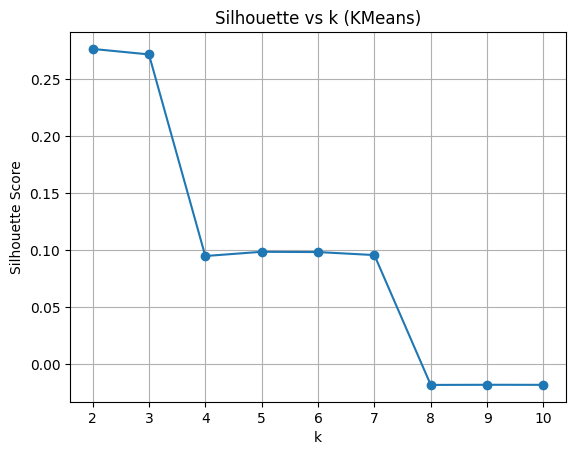

In [236]:
# Análise da Variação do número de clusters para KMeans
scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(user_movie_scaled_clean)
    score = silhouette_score(user_movie_scaled_clean, labels)
    scores.append(score)

plt.plot(K_range, scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs k (KMeans)")
plt.grid()
plt.show()

Este gráfico de silhueta para o KMeans indica que os melhores valores de k são 2 e 3.

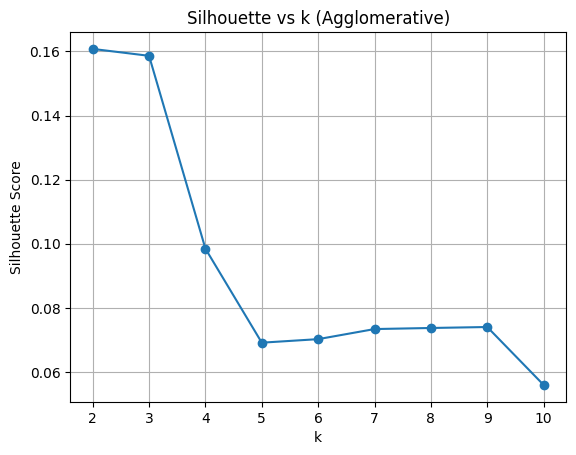

In [237]:
# Análise da Variação do número de clusters para Agglomerative
scores = []
K_range = range(2, 11)
for k in K_range:
    ac = AgglomerativeClustering(n_clusters=k)
    labels = ac.fit_predict(user_movie_scaled_clean)
    score = silhouette_score(user_movie_scaled_clean, labels)
    scores.append(score)

plt.plot(K_range, scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs k (Agglomerative)")
plt.grid()
plt.show()

Mesmo resultado para Agglomerative que para KMeans: os melhores valores de k são 2 e 3.

Esses gráficos foram obtidos após muitas tentativas, ajustando os parâmetros de filtragem dos outliers, pois mesmo com os filtros aplicados, os algoritmos KMeans e Agglomerative continuavam a formar clusters com apenas um único elemento. Com esses parâmetros atuais, finalmente consegui obter clusters mais consistentes, embora ainda bastante desequilibrados.

## Análise sem redução da dimensionalidade

Vamos aplicar os algoritmos com os valores ótimos de k encontrados.

In [ ]:
# K‑Means
print("====== KMeans ======")
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(user_movie_scaled_clean)
print(f"Silhouette KMeans: {silhouette_score(user_movie_scaled_clean, kmeans_labels):.4f}")
print("Número de elementos por cluster:", np.bincount(kmeans_labels), "\n")

====== KMeans ======
Silhouette KMeans: 0.2754
Número de elementos por cluster: [4187  713  518]


In [368]:
# Agglomerative
print("====== Agglomerative ======")
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(user_movie_scaled_clean)
print('Silhouette Agglomerative:', silhouette_score(user_movie_scaled_clean, agglo_labels))
print("Número de elementos por cluster:", np.bincount(agglo_labels))

====== Agglomerative ======
Silhouette Agglomerative: 0.17325186236891138
Número de elementos por cluster: [1001 3492  925]


Para facilitar a análise dos clusters, vamos usar uma função que exibe dois gráficos.
- O primeiro gráfico mostra os gêneros de filmes mais avaliados pelas pessoas do cluster,
 o que indica os gêneros mais assistidos, mas atenção: isso não significa que esses gêneros
 foram bem avaliados ou apreciados pelos usuários.
- Por isso, o segundo gráfico é um heatmap que mostra as notas médias atribuídas a cada gênero
 pelos usuários de cada cluster.

In [239]:
def analisar_clusters(user_clusters):
    """
    Analisa a distribuição dos gêneros e as notas médias por gênero para cada cluster de usuários.

    Parâmetros:
    - user_clusters: DataFrame com as colunas ['user_id', 'cluster']
    """
    # Mesclar com ratings e movies
    ratings_with_cluster = ratings.merge(user_clusters, on='user_id')
    ratings_with_cluster = ratings_with_cluster.merge(movies, on='movie_id')

    # Extrair os gêneros como lista
    ratings_with_cluster['genre_list'] = ratings_with_cluster['genres'].apply(lambda x: x.split('|'))

    # Explodir para ter uma linha por gênero
    genre_exploded = ratings_with_cluster.explode('genre_list')

    # Proporção de gêneros por cluster
    genre_counts = genre_exploded.groupby(['cluster', 'genre_list']).size().unstack(fill_value=0)
    genre_props = genre_counts.div(genre_counts.sum(axis=1), axis=0)

    # Exibir gráfico de barras das proporções
    genre_props.T.plot(kind='bar', figsize=(12,6))
    plt.title('Distribuição dos gêneros por cluster (%)')
    plt.ylabel('Proporção')
    plt.xlabel('Gênero')
    plt.xticks(rotation=45)
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Nota média por cluster e gênero
    avg_ratings = genre_exploded.groupby(['cluster', 'genre_list'])['rating'].mean().unstack()

    # Exibir mapa de calor
    plt.figure(figsize=(12,6))
    sns.heatmap(avg_ratings, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Nota média por gênero e por cluster')
    plt.tight_layout()
    plt.show()


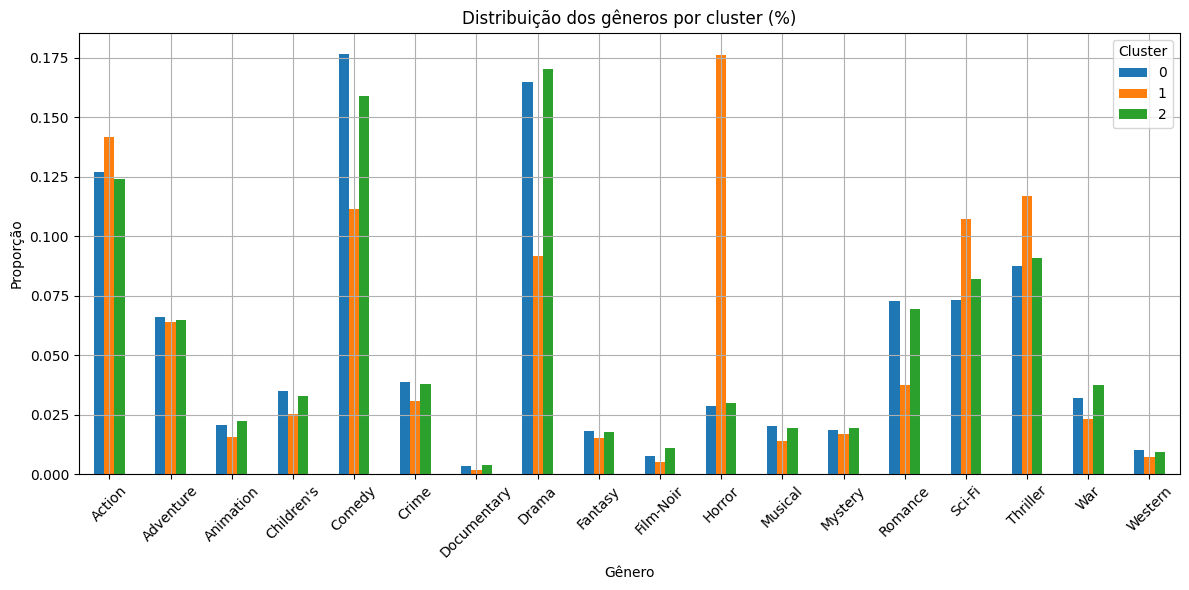

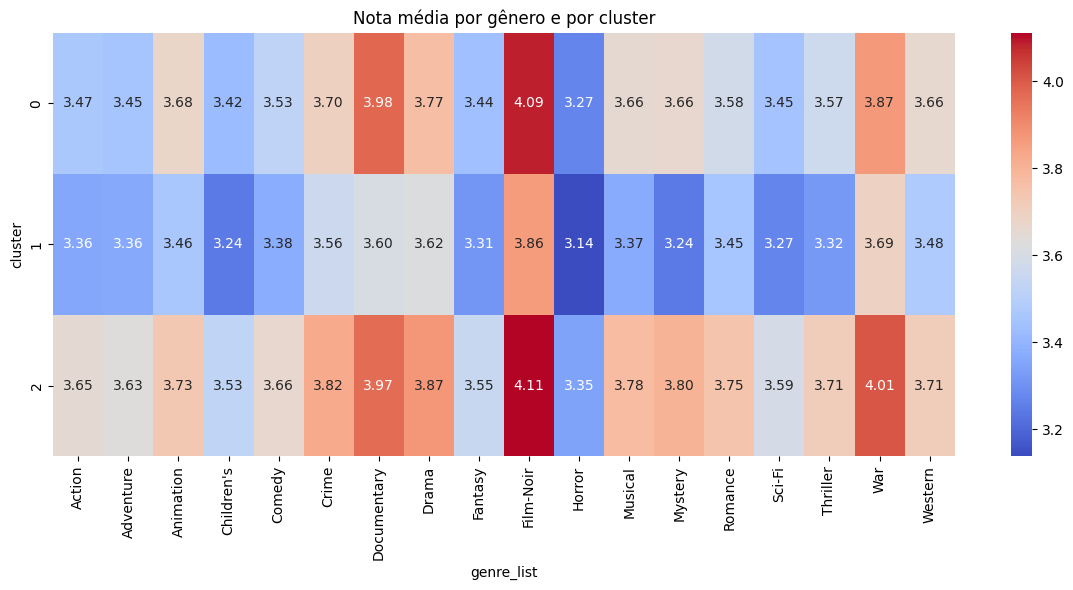

In [240]:
# Vamos analisar os clusters obtidos pelo KMeans.

user_clusters = pd.DataFrame({
    'user_id': user_movie_matrix_clean.index,
    'cluster': kmeans.labels_
})

analisar_clusters(user_clusters)

Esta primeira análise parece agrupar dois tipos distintos de usuários: um primeiro tipo de usuário (cluster 1) que assiste principalmente aos gêneros Ação, Terror, Ficção Científica e Suspense. Um segundo tipo de usuário (clusters 0 e 2) prefere gêneros como Comédia, Drama, Romance e Musical.  

O mapa de calor, por sua vez, mostra que o cluster 1 agrupa pessoas que tendem a dar notas mais baixas, independentemente do gênero.


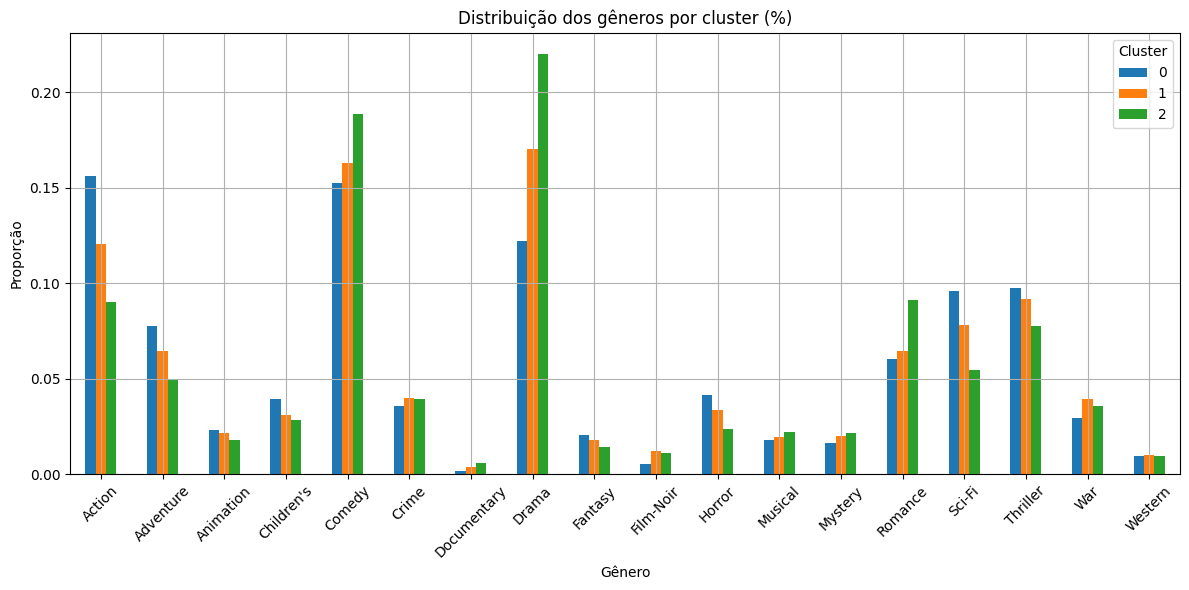

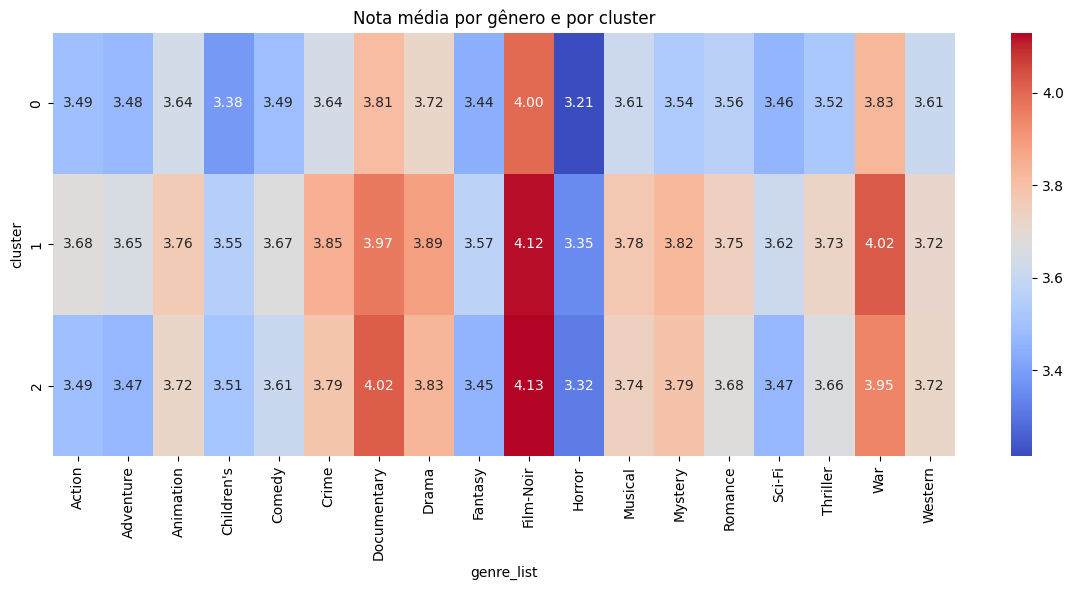

In [243]:
# Vamos analisar os clusters obtidos pelo Agglomerative.
user_clusters = pd.DataFrame({
    'user_id': user_movie_matrix_clean.index,
    'cluster': agglo.labels_
})

analisar_clusters(user_clusters)

Os clusters obtidos pelo Agglomerative parecem ter uma distribuição semelhante à do KMeans: um grupo que assiste principalmente aos gêneros Ação, Aventura, Terror, Ficção Científica e Suspense, e um segundo grupo que prefere Comédia, Drama e Romance embora a diferença aqui seja menos acentuada.

Já o mapa de calor mostra que os gostos de cada cluster são quase idênticos, com as mesmas categorias apresentando médias altas e as mesmas categorias tendo médias mais baixas.


### Cálculo das matrizes de distâncias

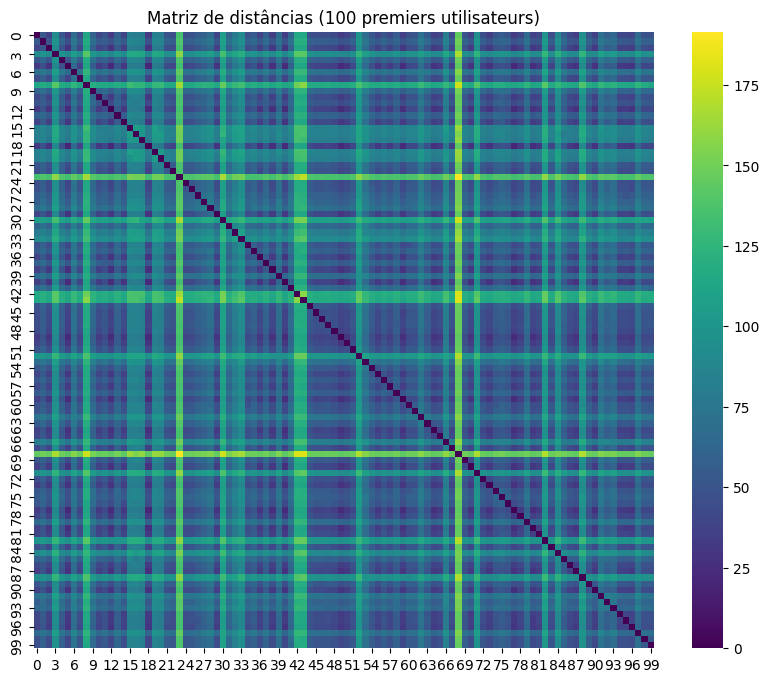

In [244]:
# Matriz de distâncias
dist_matrix = squareform(pdist(user_movie_scaled_clean, 'euclidean'))
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix[:100, :100], cmap='viridis')
plt.title("Matriz de distâncias (100 primeiros usuários)")
plt.show()

A matriz de distâncias não exibe informações ou padrões realmente relevantes.

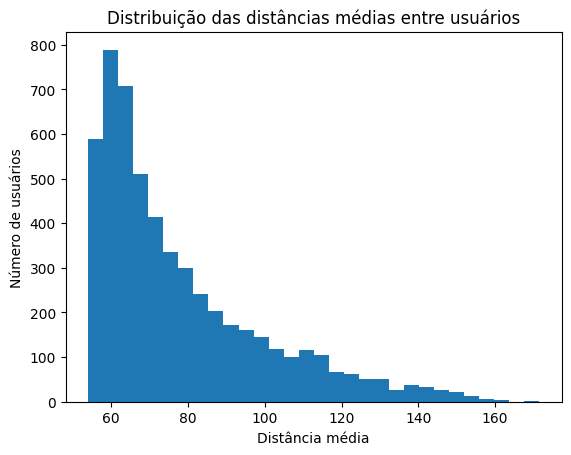

In [245]:
# Distribuição das distâncias médias entre usuários
user_avg_dist = dist_matrix.mean(axis=1)

plt.hist(user_avg_dist, bins=30)
plt.title("Distribuição das distâncias médias entre usuários")
plt.xlabel("Distância média")
plt.ylabel("Número de usuários")
plt.show()

## Redução de dimensionalidade (PCA)

Agora vamos reduzir a dimensionalidade da matriz para poder aplicar o DBSCAN.

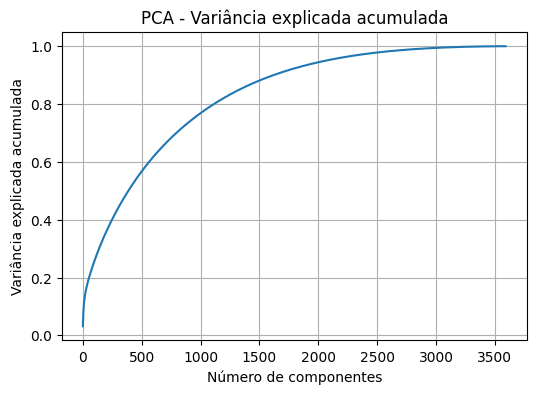

In [336]:
# Análise de PCA para redução de dimensionalidade
pca = PCA()
pca_t = pca.fit_transform(user_movie_scaled_clean)

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.title('PCA - Variância explicada acumulada')
plt.grid()
plt.show()

O objetivo da variância explicada acumulada é identificar quantas componentes principais são necessárias para explicar a maior parte da variância dos dados. Não devemos exceder 50 dimensões para poder aplicar o DBSCAN; aqui, 50 dimensões correspondem a cerca de 20% da variância dos dados.

In [371]:
# Escolha do número de componentes
pca_n = PCA(n_components=50)
pca_data = pca_n.fit_transform(user_movie_scaled_clean)

Aplicamos o DBSCAN e verificamos quantos elementos há em cada cluster.

In [372]:
# DBSCAN
dbscan = DBSCAN(eps=3, min_samples=10)
dbscan_labels = dbscan.fit_predict(pca_data)
print('Clusters DBSCAN (excluindo outliers):', len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
cluster_counts = Counter(dbscan_labels)
print("Número de elementos por cluster:")
for label, count in sorted(cluster_counts.items()):
    print(f"  Cluster {label}: {count}")
print()

Clusters DBSCAN (excluindo outliers): 2
Número de elementos por cluster:
  Cluster -1: 5210
  Cluster 0: 58
  Cluster 1: 150



Mesmo ajustando os parâmetros, o DBSCAN coloca a maioria dos elementos no cluster -1, que corresponde aos outliers; reduzir para menos de 50 dimensões não resolve o problema.

Vamos remover os outliers detectados pelo DBSCAN e reaplicar os algoritmos KMeans e Agglomerative.


In [373]:
# Remoção de outliers

# Criar uma máscara para manter apenas os pontos que não são outliers
core_mask = dbscan_labels != -1

# Aplicar essa máscara aos dados PCA
pca_data_core = pca_data[core_mask]

# Filtrar a matriz usuário-filme limpa (linha = usuário)
user_movie_matrix_core = user_movie_matrix_clean.iloc[core_mask]

dbscan_labels_core = dbscan_labels[core_mask]

In [374]:
# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(pca_data_core)
print('Silhouette KMeans:', silhouette_score(pca_data_core, kmeans_labels))
print('KMeans - Número de elementos por cluster:', np.bincount(kmeans_labels))

Silhouette KMeans: 0.3035592208786665
KMeans - Número de elementos por cluster: [ 31  58 119]


In [375]:
# Agglomerative
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(pca_data_core)
print('Silhouette Agglomerative:', silhouette_score(pca_data_core, agglo_labels))
print('Agglomerative - Número de elementos por cluster:', np.bincount(agglo_labels))

Silhouette Agglomerative: 0.3022493930275857
Agglomerative - Número de elementos por cluster: [118  59  31]


## Análise com redução da dimensionalidade (PCA)

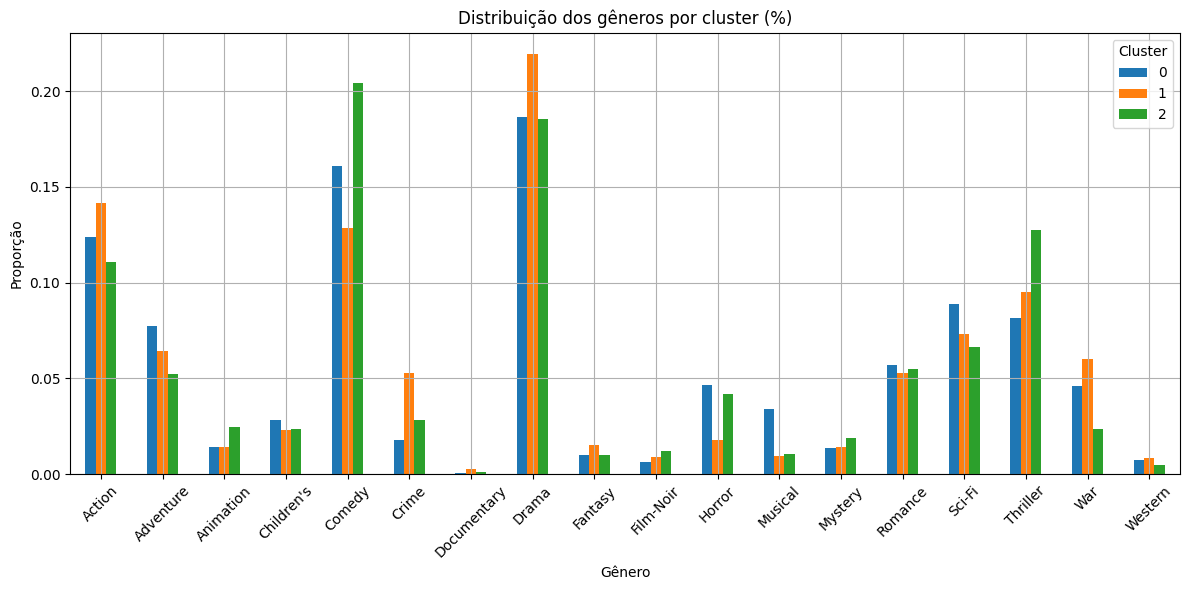

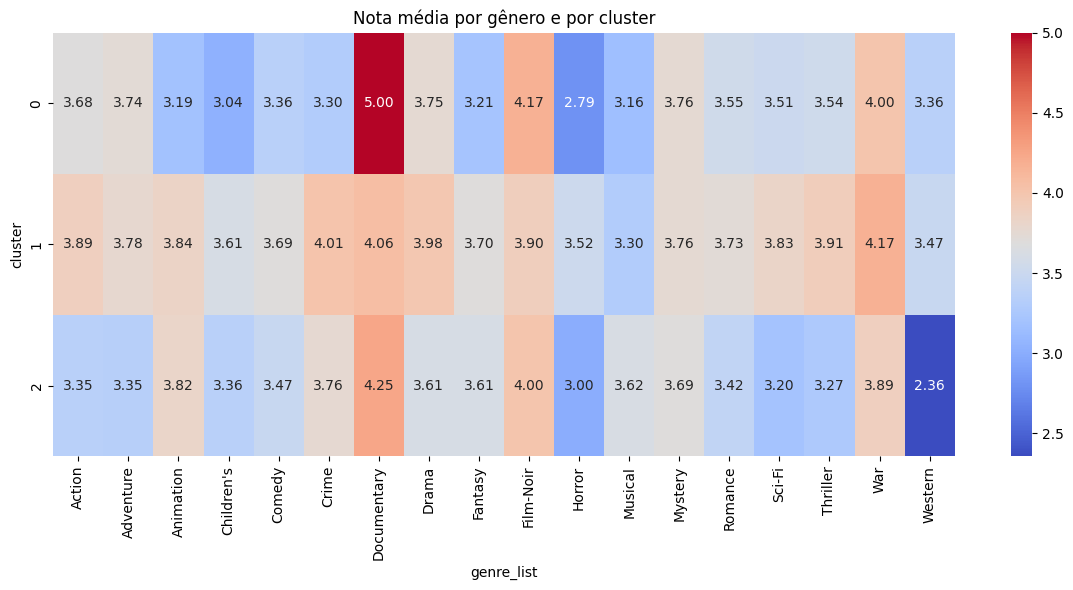

In [288]:
# Vamos analisar os clusters obtidos pelo KMeans.

user_clusters = pd.DataFrame({
    'user_id': user_movie_matrix_core.index,
    'cluster': kmeans.labels_
})

analisar_clusters(user_clusters)

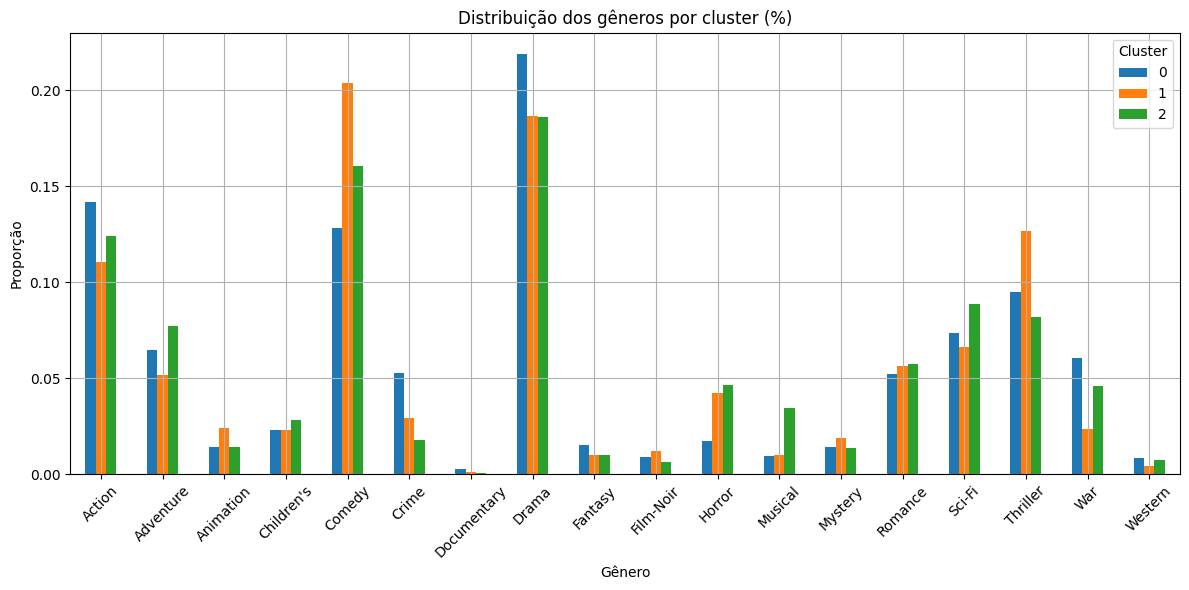

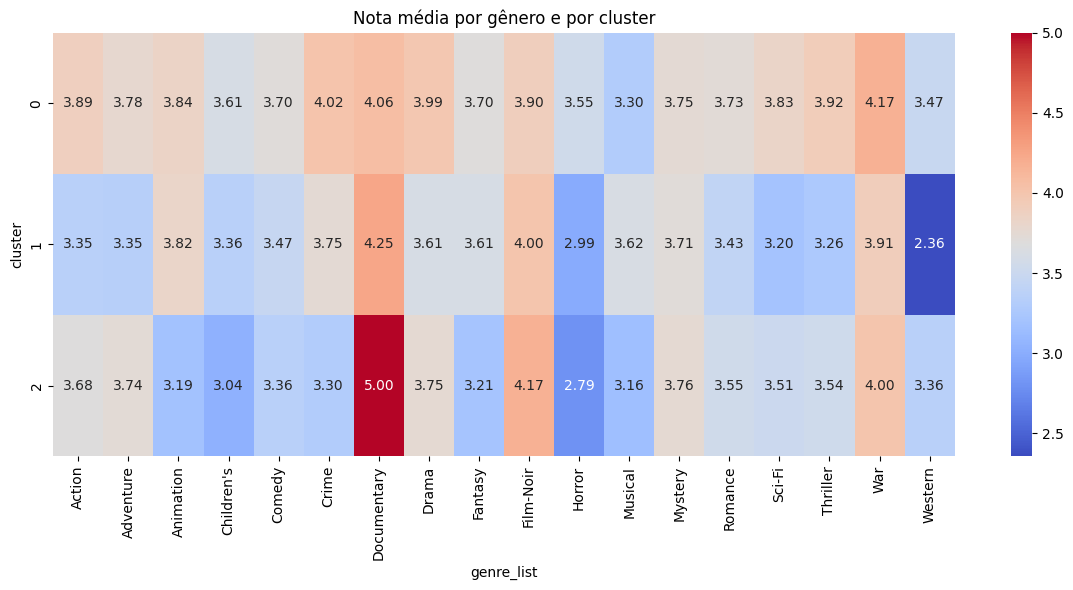

In [289]:
# Vamos analisar os clusters obtidos pelo Agglo.
user_clusters = pd.DataFrame({
    'user_id': user_movie_matrix_core.index,
    'cluster': agglo.labels_
})

analisar_clusters(user_clusters)

Os resultados obtidos pelo KMeans e Agglomerative são novamente muito próximos, mas parecem não trazer informações novas; as diferenças entre os clusters não são suficientes para tirar conclusões.

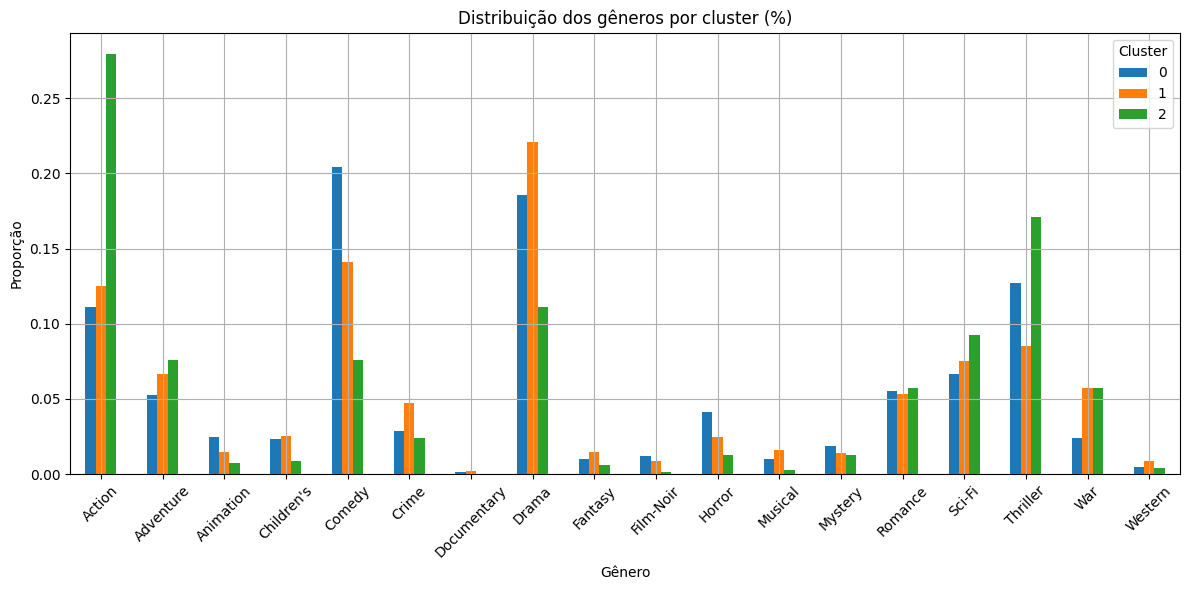

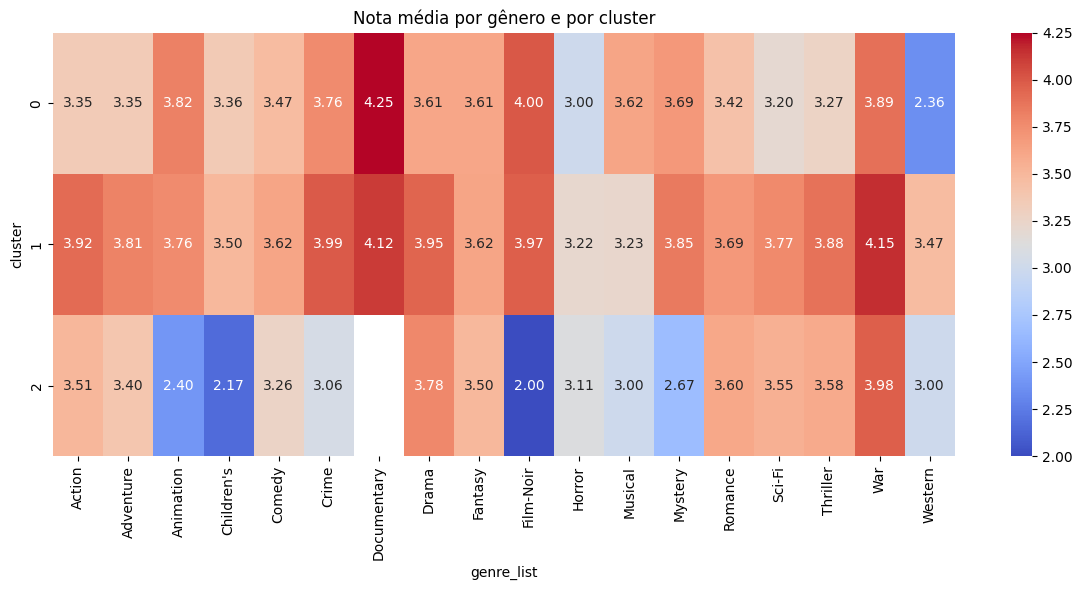

In [290]:
# Vamos analisar os clusters obtidos pelo DBScan.
user_clusters = pd.DataFrame({
    'user_id': user_movie_matrix_core.index,
    'cluster': dbscan_labels_core
})

analisar_clusters(user_clusters)

Os clusters obtidos pelo DBSCAN são bem definidos e parecem chegar às mesmas conclusões de antes da redução de dimensionalidade: um primeiro grupo assiste a Action, Aventura, Thriller, Sci-fi, enquanto o outro grupo (composto pelos clusters 0 e 1) assiste principalmente a Comedy, Drama, Horror e Musical.

A heatmap mostra que os clusters 0 e 1 parecem agrupar os pontos com as notas mais altas, enquanto o cluster 2 dá indicações sobre os gostos: as pessoas que assistem bastante a Action, Aventura, Thriller e Sci-fi gostam desses gêneros, mas dão notas baixas para os gêneros Animation, Children's, FilmNoir e Mystery.

## Redução de dimensionalidade (SVD)

Vamos agora tentar reduzir as dimensões com Truncated SVD.
Assim como no PCA, vamos reduzir para 50 componentes.

In [304]:
# Número de componentes a manter
n_components = 10

# Aplicar TruncatedSVD
svd = TruncatedSVD(n_components=n_components, random_state=42)
svd_data = svd.fit_transform(user_movie_matrix_clean)

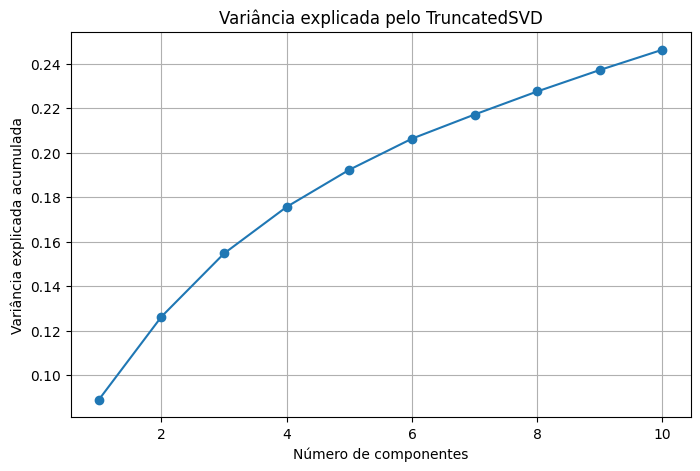

In [305]:
# Variância explicada acumulada pelo TruncatedSVD
cumulative_variance = np.cumsum(svd.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), cumulative_variance, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.title('Variância explicada pelo TruncatedSVD')
plt.grid(True)
plt.show()

10 componentes permitem explicar mais de 25% da variância.

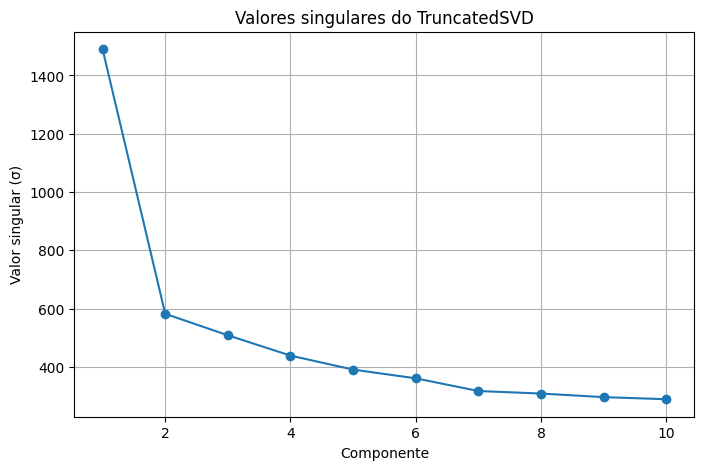

In [306]:
# Os valores singulares do TruncatedSVD
singular_values = svd.singular_values_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(singular_values)+1), singular_values, marker='o')
plt.title('Valores singulares do TruncatedSVD')
plt.xlabel('Componente')
plt.ylabel('Valor singular (σ)')
plt.grid(True)
plt.show()

As valores singulares da decomposição SVD caem muito rapidamente após as primeiras componentes, indicando que a maior parte da informação está concentrada em poucas dimensões. Por isso, optei por manter apenas 10 componentes, buscando um bom equilíbrio entre uma redução significativa da dimensionalidade e a preservação da maior parte das informações relevantes.

In [320]:
# DBSCAN
dbscan = DBSCAN(eps=3, min_samples=10)
dbscan_labels = dbscan.fit_predict(pca_data)
print('Clusters DBSCAN (excluindo outliers):', len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
cluster_counts = Counter(dbscan_labels)
print("Número de elementos por cluster:")
for label, count in sorted(cluster_counts.items()):
    print(f"  Cluster {label}: {count}")
print()

Clusters DBSCAN (excluindo outliers): 3
Número de elementos por cluster:
  Cluster -1: 5206
  Cluster 0: 57
  Cluster 1: 134
  Cluster 2: 10



In [315]:
# Remoção de outliers

# Criar uma máscara para manter apenas os pontos que não são outliers
core_mask = dbscan_labels != -1

# Aplicar essa máscara aos dados PCA
data_core_svd = svd_data[core_mask]

# Filtrar a matriz usuário-filme limpa (linha = usuário)
user_movie_matrix_core_svd = user_movie_matrix_clean.iloc[core_mask]

dbscan_labels_core_svd = dbscan_labels[core_mask]


In [321]:
# K‑Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(data_core_svd)
print('Silhouette KMeans:', silhouette_score(data_core_svd, kmeans_labels))
print('KMeans - Número de elementos por cluster:', np.bincount(kmeans_labels))

Silhouette KMeans: 0.2546048237560482
KMeans - Número de elementos por cluster: [77 65 59]


In [322]:
# Agglomerative
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(data_core_svd)
print('Silhouette Agglomerative:', silhouette_score(data_core_svd, agglo_labels))
print('Agglomerative - Número de elementos por cluster:', np.bincount(agglo_labels))

Silhouette Agglomerative: 0.2504790915923472
Agglomerative - Número de elementos por cluster: [81 58 62]


## Análise com redução da dimensionalidade (SVD)

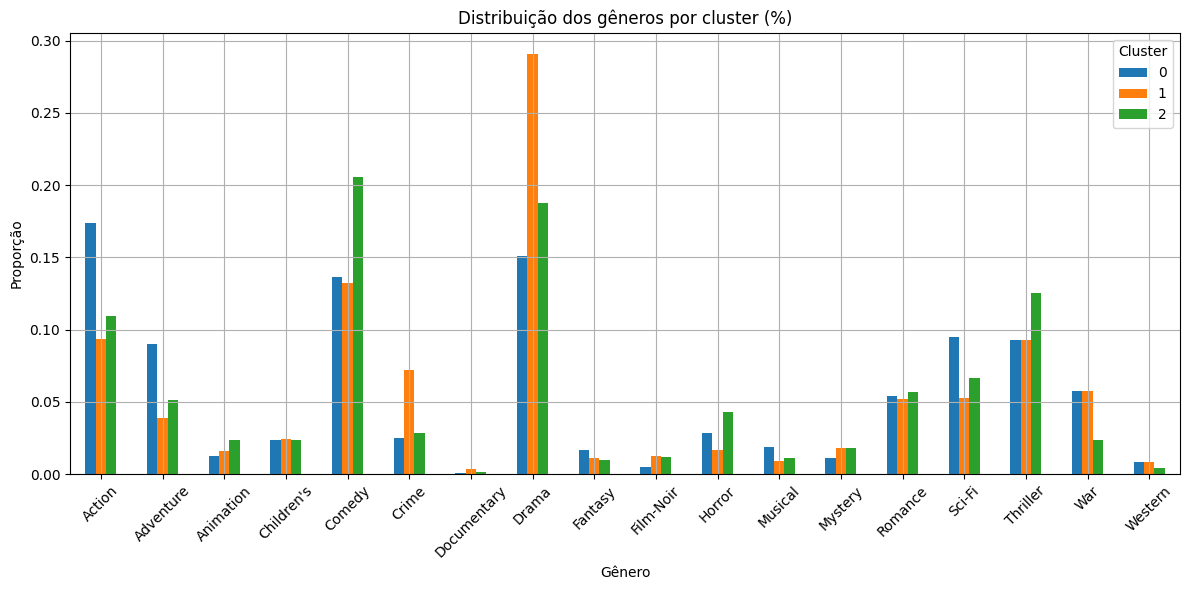

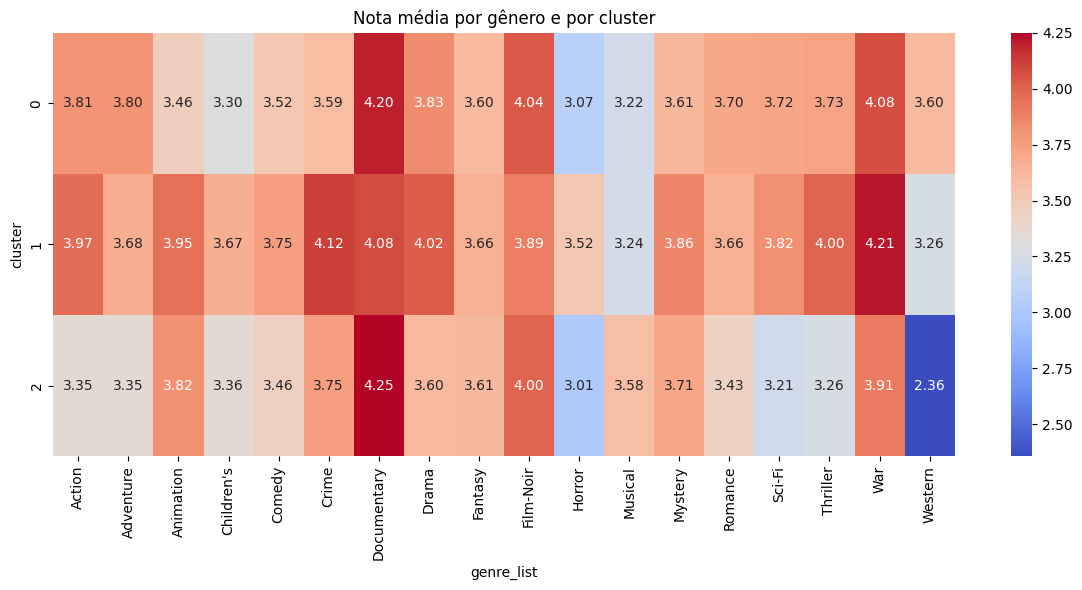

In [323]:
# Vamos analisar os clusters obtidos pelo KMeans.

user_clusters = pd.DataFrame({
    'user_id': user_movie_matrix_core.index,
    'cluster': kmeans.labels_
})

analisar_clusters(user_clusters)

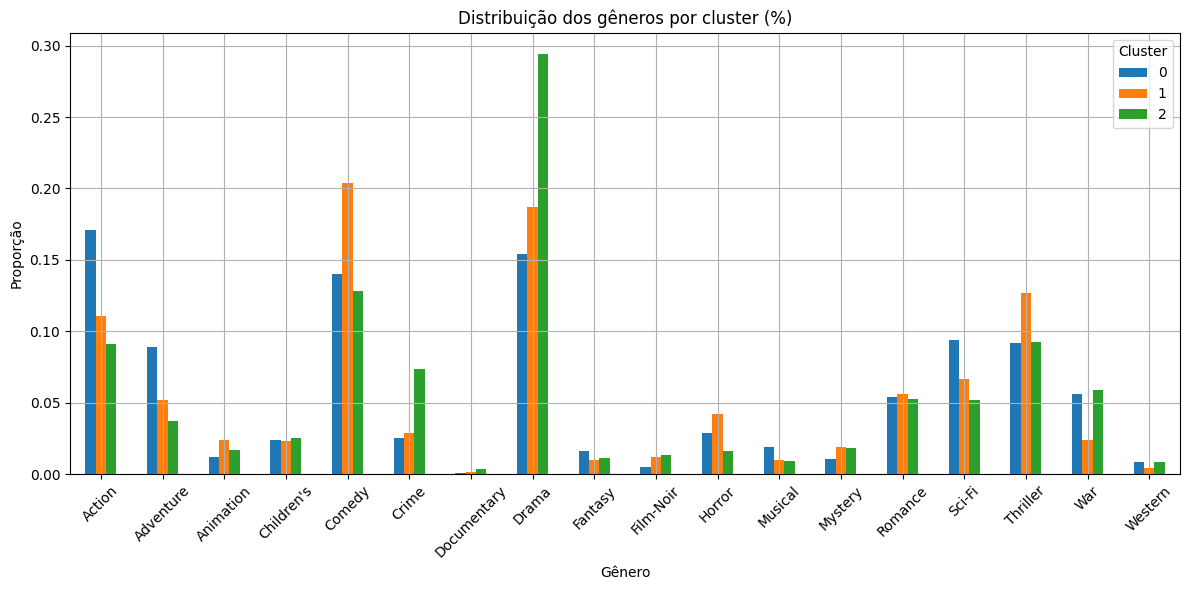

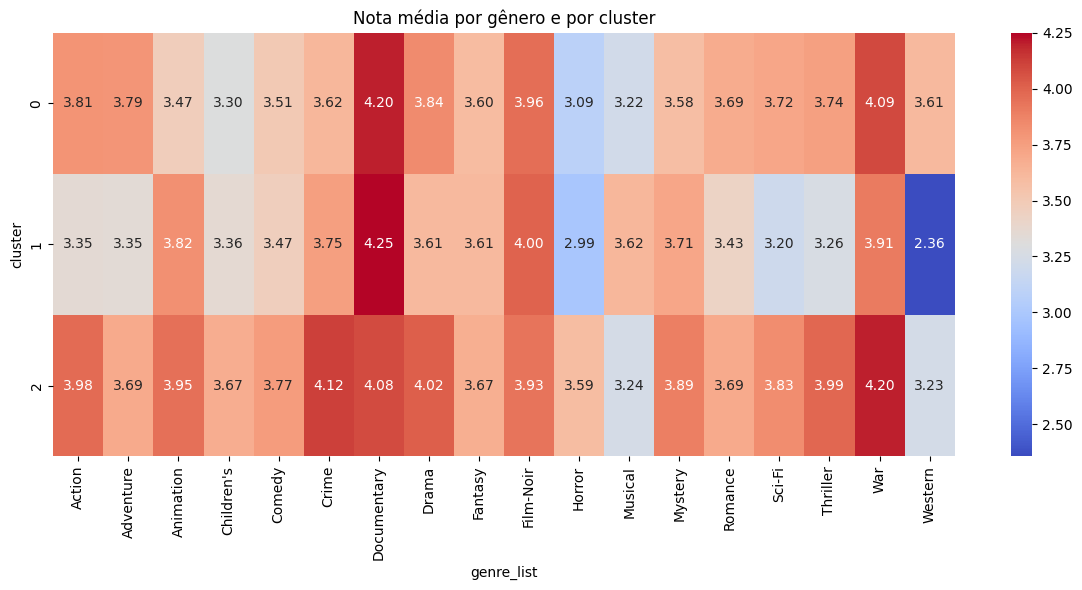

In [324]:
# Vamos analisar os clusters obtidos pelo Agglomerative.

user_clusters = pd.DataFrame({
    'user_id': user_movie_matrix_core.index,
    'cluster': agglo.labels_
})

analisar_clusters(user_clusters)

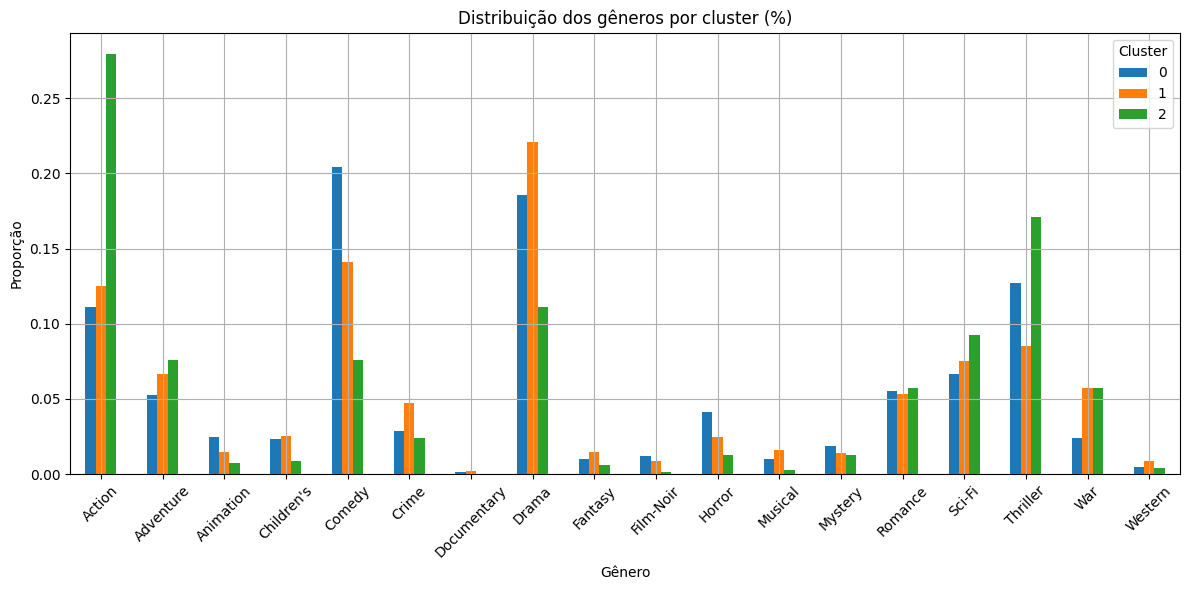

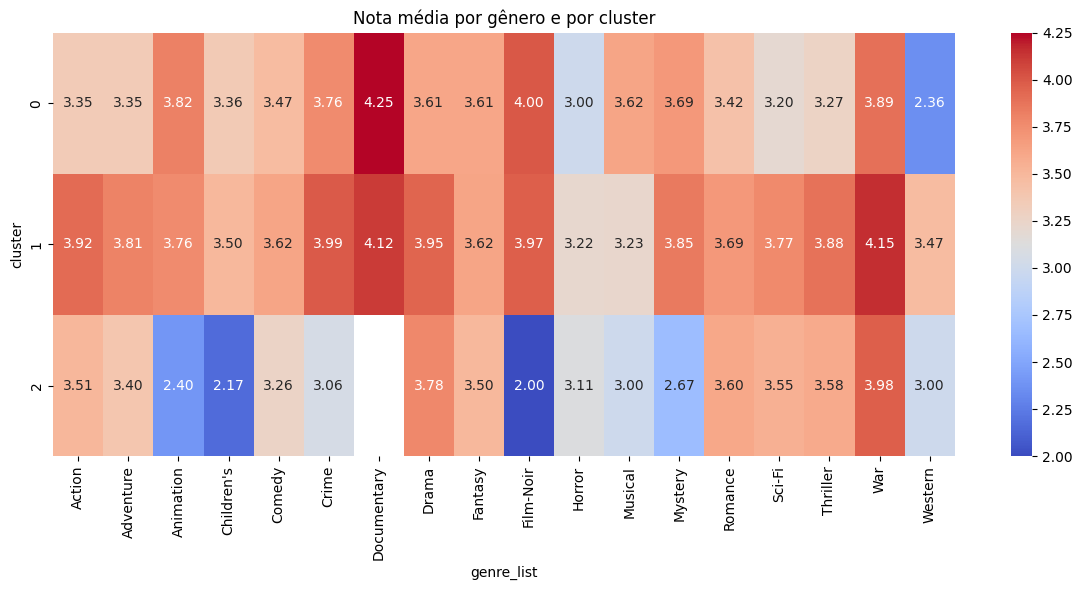

In [325]:
# Vamos analisar os clusters obtidos pelo DBScan.

user_clusters = pd.DataFrame({
    'user_id': user_movie_matrix_core.index,
    'cluster': dbscan_labels_core
})

analisar_clusters(user_clusters)

Os resultados obtidos pelo SVD são idênticos aos obtidos pela PCA, mesmo com uma redução de dimensão maior (10 dimensões).

## Conclusão

Primeiramente, remover os outliers: é muito difícil obter clusters bem distribuídos ao aplicar KMeans e Agglomerative em alta dimensão. Apesar das minhas várias tentativas com diferentes métodos para remover os outliers corretamente, e mesmo ajustando os parâmetros, sempre obtenho clusters com apenas um elemento, o que os torna não analisáveis.

Em segundo lugar, a redução de dimensionalidade com PCA ou SVD produz resultados bastante similares em ambos os casos. Pelo menos foi isso que observei após diversas tentativas, com dimensões muito reduzidas ou não. Por fim, mantive uma dimensão de 50 com PCA e uma dimensão menor, de 10, com SVD para ter as duas análises, mas os resultados ainda assim foram bastante parecidos.

Por fim, a partir deste exercício, identificamos dois grupos de usuários:

- Um que assiste majoritariamente aos gêneros: Ação, Aventura, Sci-fi, Thriller e que não gosta dos gêneros Animação, Infantil, Film Noir e Mistério.

- Outro que assiste majoritariamente aos gêneros: Comédia, Drama, Romance e Musical.

Se tivéssemos avançado para implementar um algoritmo de recomendação, ele poderia sugerir filmes dos gêneros correspondentes a cada um desses grupos.